<a href="https://colab.research.google.com/github/naveen-ramavath/Deep-Learning/blob/main/dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# week 1

1)Build a Simple Neural Network with PyTorch

In [ ]:
!pip install keras

In [ ]:
# Build a simple neural network with pytorch

import torch
import torch.nn as nn
import torch.optim as optim

#creating a dummy dataset
x = torch.randn(100,3)
y = torch.randn(100,1)

class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(3,1)

  def forward(self, x):
    return self.linear(x)

model = SimpleNN()
lossfn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

for epoch in range(100):
  y_pred = model(x)
  loss = lossfn(y_pred, y)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


print("final loss")
print(loss.item())

final loss
1.0315812826156616


2)Simple Neural Network with TensorFlow


In [ ]:
#Simple Neural Network with TensorFlow

import tensorflow as tf
x = tf.random.normal((100,3))
y = tf.random.normal((100,1))

model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape= (3,))])

model.compile(optimizer= 'adam', loss = 'mse')
model.fit(x, y, epochs = 100, verbose = 0)

print("final loss")
print(model.evaluate(x, y))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


final loss
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7712 
1.5820753574371338


In [ ]:
#using keras
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

model = keras.Sequential([
    layers.Dense(1, input_shape=(3,))
])

model.compile(optimizer='adam', loss='mse')

model.fit(x, y, epochs=100, verbose=0)

print("Final loss:", model.evaluate(x, y))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.5668 
Final loss: 1.5706777572631836


In [ ]:
#simple perceptron

import numpy as np

def step(x):
  return 1 if x>= 0 else 0

class Perceptron:
  def __init__(self, w, b):
    self.w = w
    self.b = b

  def forward(self, x):
    sum = np.dot(self.w, x) + self.b
    return step(sum)

#AND Gate parameters
w = np.array([0.5,0.5])
b = -0.7

andgate = Perceptron(w, b)

for x in [(0,0), (0,1), (1,0), (1,1)]:
  print(x, "->", andgate.forward(np.array(x)))


(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


# week 2

Q1. Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)

In [ ]:
#SIMPLE AND
import numpy as np

def step(x):
  return 1 if x>= 0 else 0

class Perceptron:
  def __init__(self, w, b):
    self.w = w
    self.b = b

  def forward(self, x):
    sum = np.dot(self.w, x) + self.b
    return step(sum)

#AND Gate parameters
w = np.array([0.5,0.5])
b = -0.7

andgate = Perceptron(w, b)

for x in [(0,0), (0,1), (1,0), (1,1)]:
  print(x, "->", andgate.forward(np.array(x)))


(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1



Q3. Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.

In [ ]:
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        net = self.bias
        for i in range(len(x)):
            net += self.weights[i] * x[i]
        return 1 if net >= 0 else 0
#XOR
# Hidden layer perceptrons
p_or  = Perceptron([1, 1], -0.5)   # OR gate
p_and = Perceptron([1, 1], -1.5)   # AND gate

# Output perceptron
p_xor = Perceptron([1, -1], -0.5)
print("XOR Output:")
inputs = [(0,0), (0,1), (1,0), (1,1)]

for x in inputs:
    h1 = p_or.activate(x)
    h2 = p_and.activate(x)
    output = p_xor.activate([h1, h2])
    print(x, "->", output)

#XNOR
# NOT perceptron
p_not = Perceptron([-1], 0.5)

print("\nXNOR Output:")

for x in inputs:
    h1 = p_or.activate(x)
    h2 = p_and.activate(x)
    xor_out = p_xor.activate([h1, h2])
    xnor_out = p_not.activate([xor_out])
    print(x, "->", xnor_out)


XOR Output:
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0

XNOR Output:
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


Q4. Demonstrate that the thresholding logic used by perceptron is very harsh.

In [ ]:
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        net = self.bias
        for i in range(len(x)):
            net += self.weights[i] * x[i]
        return 1 if net >= 0 else 0
# Same perceptron
p = Perceptron(weights=[1, 1], bias=-1.5)

inputs = [
    [1, 0.49],   # slightly below threshold
    [1, 0.50],   # exactly at threshold
    [1, 0.51]    # slightly above threshold
]

print("Harsh Thresholding Demonstration:\n")

for x in inputs:
    output = p.activate(x)
    print("Input:", x, "Output:", output)



Harsh Thresholding Demonstration:

Input: [1, 0.49] Output: 0
Input: [1, 0.5] Output: 1
Input: [1, 0.51] Output: 1



Q5. Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as determining whether a user would like to watch a movie. Note: Consider a small dataset(design your own excel csv sheet) of movie records with Boolean or real-valued features, for example: f1​: Is actor Matt Damon present f2​: Is the genre Thriller f3​: Is the director Christopher Nolan f4: IMDb rating (scaled between 0 and 1) The output label represents like (1) or dislike (0). Train the perceptron model using these features and observe how weight updates influence convergence and classification performance. Test with a sample record to show whether a perceptron properly classifies it or not. i) Check with MP Perceptron (without weights and bias) ii) Check with Perceptron (with weights) iii) Check with Perceptron (with weights and bias)

In [ ]:
import pandas as pd
import numpy as np

# Dataset with 5 records
data = {
    'f1': [1, 0, 1, 0, 1],     # Matt Damon
    'f2': [1, 1, 0, 0, 1],     # Thriller
    'f3': [0, 1, 1, 0, 1],     # Christopher Nolan
    'f4': [0.85, 0.90, 0.75, 0.40, 0.95],  # IMDb rating
    'y' : [1, 1, 1, 0, 1]     # Like / Dislike
}

movie_df = pd.DataFrame(data)
print(movie_df)

X = movie_df[['f1','f2','f3','f4']].values
y = movie_df['y'].values


   f1  f2  f3    f4  y
0   1   1   0  0.85  1
1   0   1   1  0.90  1
2   1   0   1  0.75  1
3   0   0   0  0.40  0
4   1   1   1  0.95  1


In [ ]:
#MP perceptron (no weights, no bias)
def step(z):
    if z >= 0:
        return 1
    else:
        return 0

def mp_perceptron(x):
    total = 0
    for v in x:
        total += v
    return step(total)

print("\nMP Perceptron Output:")
for i in range(len(X)):
    pred = mp_perceptron(X[i])
    print("Input:", X[i], "True:", y[i], "Pred:", pred)



MP Perceptron Output:
Input: [1.   1.   0.   0.85] True: 1 Pred: 1
Input: [0.  1.  1.  0.9] True: 1 Pred: 1
Input: [1.   0.   1.   0.75] True: 1 Pred: 1
Input: [0.  0.  0.  0.4] True: 0 Pred: 1
Input: [1.   1.   1.   0.95] True: 1 Pred: 1


In [ ]:
#perceptron with weights only, no bias
weights = np.zeros(4)
learning_rate = 0.1
epochs = 10

print("\nPerceptron with Weights Only:")

for epoch in range(epochs):
    errors = 0
    for i in range(len(X)):
        net = 0
        for j in range(4):
            net += weights[j] * X[i][j]

        y_pred = step(net)
        error = y[i] - y_pred

        for j in range(4):
            weights[j] += learning_rate * error * X[i][j]

        errors += abs(error)

    print("Epoch", epoch+1, "Errors:", errors)
    if errors == 0:
        break

print("Final Weights (No Bias):", weights)
weights_no_bias = weights.copy()



Perceptron with Weights Only:
Epoch 1 Errors: 2
Epoch 2 Errors: 1
Epoch 3 Errors: 1
Epoch 4 Errors: 0
Final Weights (No Bias): [ 0.1    0.1    0.1   -0.025]


In [ ]:
#perceptron with both weights and bias
weights = np.zeros(4)
bias = 0

print("\nPerceptron with Weights and Bias:")

for epoch in range(epochs):
    errors = 0
    for i in range(len(X)):
        net = bias
        for j in range(4):
            net += weights[j] * X[i][j]

        y_pred = step(net)
        error = y[i] - y_pred

        for j in range(4):
            weights[j] += learning_rate * error * X[i][j]

        bias += learning_rate * error
        errors += abs(error)

    print("Epoch", epoch+1, "Errors:", errors)
    if errors == 0:
        break

print("Final Weights:", weights)
print("Final Bias:", bias)



Perceptron with Weights and Bias:
Epoch 1 Errors: 2
Epoch 2 Errors: 1
Epoch 3 Errors: 0
Final Weights: [0.1   0.1   0.1   0.015]
Final Bias: -0.1


In [ ]:
test_movie = [1, 1, 0, 0.80]

# MP
mp_result = mp_perceptron(test_movie)

# Weights only
net = 0
for j in range(4):
    net += weights[j] * test_movie[j]
no_bias_result = step(net)

# Weights + bias
net = bias
for j in range(4):
    net += weights[j] * test_movie[j]
bias_result = step(net)

print("\nTest Movie:", test_movie)
print("MP Perceptron:", mp_result)
print("Weights Only:", no_bias_result)
print("Weights + Bias:", bias_result)



Test Movie: [1, 1, 0, 0.8]
MP Perceptron: 1
Weights Only: 1
Weights + Bias: 1


Q6. Demonstrate the Representation Power of a Network of Perceptrons How many Boolean functions can be designed using two binary inputs? For each Boolean function, determine whether it is linearly separable. Implement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why) Extend the program to estimate or analyze how the number of non-linearly separable Boolean functions increases as the number of inputs n grows.

In [ ]:
import numpy as np
from itertools import product

# Step function
def step(x):
    return 1 if x >= 0 else 0

# Train single perceptron
def train_perceptron(X, y):
    w = np.zeros(2)
    b = 0

    for _ in range(30):
        error_count = 0
        for i in range(len(X)):
            net = w[0]*X[i][0] + w[1]*X[i][1] + b
            y_pred = step(net)
            error = y[i] - y_pred

            w[0] += error * X[i][0]
            w[1] += error * X[i][1]
            b += error

            error_count += abs(error)

        if error_count == 0:
            return True
    return False

# Inputs (2-bit)
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Generate all Boolean functions
functions = list(product([0,1], repeat=4))

linear = 0
non_linear = 0

for f in functions:
    y = np.array(f)
    if train_perceptron(X, y):
        linear += 1
    else:
        non_linear += 1

print("Total Boolean functions:", len(functions))
print("Linearly separable:", linear)
print("Not linearly separable:", non_linear)


Total Boolean functions: 16
Linearly separable: 14
Not linearly separable: 2


Q7. Design and implement a Multi-Layer Perceptron (MLP) architecture capable of realizing all basic Boolean functions Picture1.png

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

# hidden layer perceptrons
def hidden_layer(x1,x2):

    h1 = step((-1*x1) + (-1*x2) + 0)   # detects (0,0)
    h2 = step((-1*x1) + (1*x2) -1)     # detects (0,1)
    h3 = step((1*x1) + (-1*x2) -1)     # detects (1,0)
    h4 = step((1*x1) + (1*x2) -2)      # detects (1,1)

    return [h1,h2,h3,h4]


def mlp_boolean(x1,x2,w):

    h = hidden_layer(x1,x2)

    y = w[0]*h[0] + w[1]*h[1] + w[2]*h[2] + w[3]*h[3]

    return step(y)


# example: XOR
weights = [0,1,1,0]

inputs = [(0,0),(0,1),(1,0),(1,1)]

for x in inputs:
    print(x,"->",mlp_boolean(x[0],x[1],weights))

(0, 0) -> 1
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1


In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        total = self.bias
        for i in range(len(x)):
            total += self.weights[i] * x[i]
        return 1 if total >= 0 else 0

class MLP_boolean_functions:
    def __init__(self, out_weights, out_bias):
        self.out_weights = out_weights
        self.out_bias = out_bias

        # Hidden layer: each neuron fires for one input
        self.hidden = [
            Perceptron([-1,  1], -0.5),   # (0,1)
            Perceptron([-1, -1],  0.5),   # (0,0)
            Perceptron([ 1, -1], -0.5),   # (1,0)
            Perceptron([ 1,  1], -1.5)    # (1,1)
        ]

    def predict(self, x):
        result = 0
        for i in range(4):
            result += self.hidden[i].activate(x) * self.out_weights[i]
        return step(result + self.out_bias)
X = [
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]
print("AND")
AND = MLP_boolean_functions([0, 0, 0, 1], -0.5)
for x in X:
    print(x, "->", AND.predict(x))
print("\nOR")
OR = MLP_boolean_functions([0, 1, 1, 1], -0.5)
for x in X:
    print(x, "->", OR.predict(x))
print("\nXOR")
XOR = MLP_boolean_functions([0, 1, 1, 0], -0.5)
for x in X:
    print(x, "->", XOR.predict(x))

AND
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1

OR
[0, 0] -> 1
[0, 1] -> 0
[1, 0] -> 1
[1, 1] -> 1

XOR
[0, 0] -> 1
[0, 1] -> 0
[1, 0] -> 1
[1, 1] -> 0



Q8. How many Boolean functions can be designed using three binary inputs? Find respective weights w1 to w8 and demonstrate for all the possible boolean functions for three inputs

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1,x2,x3):

    h1 = step(-x1 -x2 -x3 +0)
    h2 = step(-x1 -x2 +x3 -1)
    h3 = step(-x1 +x2 -x3 -1)
    h4 = step(-x1 +x2 +x3 -2)
    h5 = step(x1 -x2 -x3 -1)
    h6 = step(x1 -x2 +x3 -2)
    h7 = step(x1 +x2 -x3 -2)
    h8 = step(x1 +x2 +x3 -3)

    return [h1,h2,h3,h4,h5,h6,h7,h8]


def mlp_boolean(x1,x2,x3,w):

    h = hidden_layer(x1,x2,x3)

    y = 0
    for i in range(8):
        y += w[i]*h[i]

    return step(y)


weights = [0,1,0,1,1,0,0,1]

inputs = [
(0,0,0),(0,0,1),(0,1,0),(0,1,1),
(1,0,0),(1,0,1),(1,1,0),(1,1,1)
]

for x in inputs:
    print(x,"->",mlp_boolean(x[0],x[1],x[2],weights))

(0, 0, 0) -> 1
(0, 0, 1) -> 1
(0, 1, 0) -> 1
(0, 1, 1) -> 1
(1, 0, 0) -> 1
(1, 0, 1) -> 1
(1, 1, 0) -> 1
(1, 1, 1) -> 1


In [ ]:
def step(x):
    return 1 if x >= 0 else 0


class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        total = self.bias
        for i in range(len(x)):
            total += self.weights[i] * x[i]
        return step(total)

class MLP_3bit:
    def __init__(self, out_weights):
        self.out_weights = out_weights
        self.out_bias = -0.5

        self.hidden = [
            Perceptron([-1,-1,-1],  0.5),  # 000
            Perceptron([-1,-1, 1], -0.5),  # 001
            Perceptron([-1, 1,-1], -0.5),  # 010
            Perceptron([-1, 1, 1], -1.5),  # 011
            Perceptron([ 1,-1,-1], -0.5),  # 100
            Perceptron([ 1,-1, 1], -1.5),  # 101
            Perceptron([ 1, 1,-1], -1.5),  # 110
            Perceptron([ 1, 1, 1], -2.5)   # 111
        ]

    def predict(self, x):
        s = 0
        for i in range(8):
            s += self.hidden[i].activate(x) * self.out_weights[i]
        return step(s + self.out_bias)
X = [
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
]
print("3-input AND")
AND3 = MLP_3bit([0,0,0,0,0,0,0,1])
for x in X:
    print(x, "->", AND3.predict(x))
print("\n3-input OR")
OR3 = MLP_3bit([0,1,1,1,1,1,1,1])
for x in X:
    print(x, "->", OR3.predict(x))
print("\nCustom Boolean Function")
CUSTOM = MLP_3bit([0,0,1,0,1,0,0,0])
for x in X:
    print(x, "->", CUSTOM.predict(x))


3-input AND
[0, 0, 0] -> 0
[0, 0, 1] -> 0
[0, 1, 0] -> 0
[0, 1, 1] -> 0
[1, 0, 0] -> 0
[1, 0, 1] -> 0
[1, 1, 0] -> 0
[1, 1, 1] -> 1

3-input OR
[0, 0, 0] -> 0
[0, 0, 1] -> 1
[0, 1, 0] -> 1
[0, 1, 1] -> 1
[1, 0, 0] -> 1
[1, 0, 1] -> 1
[1, 1, 0] -> 1
[1, 1, 1] -> 1

Custom Boolean Function
[0, 0, 0] -> 0
[0, 0, 1] -> 0
[0, 1, 0] -> 1
[0, 1, 1] -> 0
[1, 0, 0] -> 1
[1, 0, 1] -> 0
[1, 1, 0] -> 0
[1, 1, 1] -> 0


# week 3


9  Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

learning rate: 0.01,final loss: 0.24920
learning rate: 0.05,final loss: 0.24732
learning rate: 0.1,final loss: 0.24061
learning rate: 0.5,final loss: 0.01261
learning rate: 1.0,final loss: 0.00255


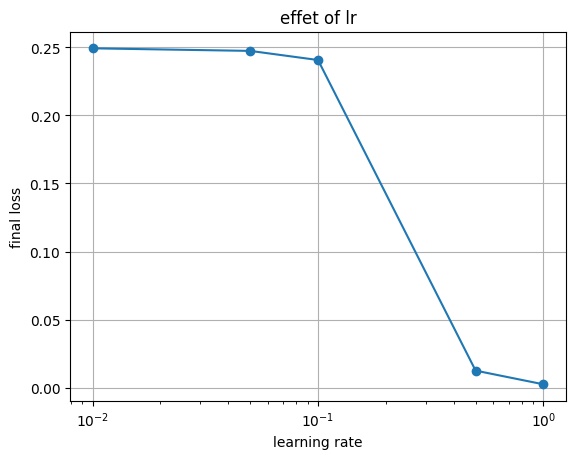

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
  return 1/(1+np.exp(-x))
def sigmoid_derivative(x):
  return x*(1-x)

x=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

l_r=[0.01,0.05,0.1,0.5,1.0]
final_loss=[]
epochs=1000

for lr in l_r:
  np.random.seed(42)
  w1=np.random.rand(2,2)
  b1=np.random.rand(1,2)
  w2=np.random.rand(2,1)
  b2=np.random.rand(1,1)
  for epoch in range(epochs):
    hidden_input=np.dot(x,w1)+b1
    hidden_output=sigmoid(hidden_input)
    final_input=np.dot(hidden_output,w2)+b2
    y_pred=sigmoid(final_input)
    error=y-y_pred
    loss=np.mean(error**2)
    d_output=error*sigmoid_derivative(y_pred)
    d_hidden=d_output.dot(w2.T)*sigmoid_derivative(hidden_output)
    w2+=hidden_output.T.dot(d_output)*lr
    b2+=np.sum(d_output,axis=0,keepdims=True)*lr
    w1 += x.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr
  final_loss.append(loss)
  print(f"learning rate: {lr},final loss: {loss:.5f}")

plt.figure()
plt.plot(l_r,final_loss,marker='o')
plt.xlabel("learning rate")
plt.ylabel("final loss")
plt.title("effet of lr")
plt.xscale('log')
plt.grid(True)
plt.show()



#when incresing the epochs loss is decresing and
#when lr is too small loss is bid when lr is big loss also big so lr is medium




Learning Rate: 0.001 Loss: 0.2499862730126493
Learning Rate: 0.01 Loss: 0.24992790034437168
Learning Rate: 0.05 Loss: 0.2480335721394741
Learning Rate: 0.1 Loss: 0.15020478747874524
Learning Rate: 0.5 Loss: 0.0007632044651740029
Learning Rate: 1 Loss: 0.0003096242518150375


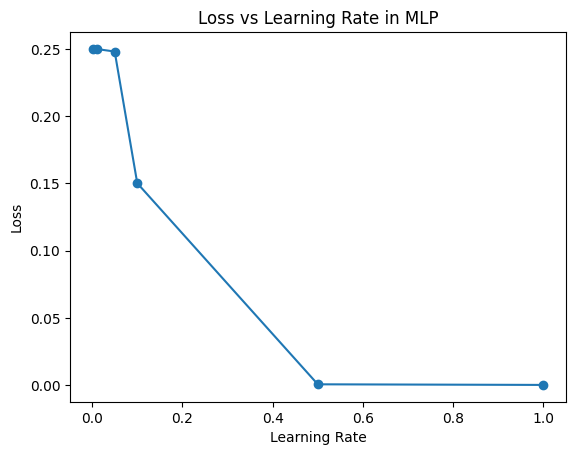

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# sigmoid activation
def sigmoid(x):
    return 1/(1+np.exp(-x))

# derivative of sigmoid
def sigmoid_derivative(x):
    return x*(1-x)

# MLP training function
def train_mlp(lr):

    np.random.seed(1)

    # weights and bias initialization
    w1 = np.random.rand(2,2)
    b1 = np.zeros((1,2))

    w2 = np.random.rand(2,1)
    b2 = np.zeros((1,1))

    for epoch in range(5000):

        # forward propagation
        hidden = sigmoid(np.dot(X,w1)+b1)
        output = sigmoid(np.dot(hidden,w2)+b2)

        # error and loss
        error = y - output
        loss = np.mean(error**2)

        # backpropagation
        d_output = error * sigmoid_derivative(output)
        d_hidden = d_output.dot(w2.T) * sigmoid_derivative(hidden)

        # weight updates
        w2 += lr * hidden.T.dot(d_output)
        b2 += lr * np.sum(d_output,axis=0)

        w1 += lr * X.T.dot(d_hidden)
        b1 += lr * np.sum(d_hidden,axis=0)

    return loss


# learning rates to test
learning_rates = [0.001,0.01,0.05,0.1,0.5,1]

loss_values = []

for lr in learning_rates:
    loss = train_mlp(lr)
    loss_values.append(loss)
    print("Learning Rate:", lr, "Loss:", loss)

# plot graph
plt.plot(learning_rates,loss_values,marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate in MLP")
plt.show()

11. Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris=load_iris()

x_train,x_test,y_train,y_test=train_test_split(iris.data,iris.target,test_size=0.3,random_state=42)

perceptron=Perceptron()

perceptron.fit(x_train,y_train)
y_pred=perceptron.predict(x_test)
acc=accuracy_score(y_test,y_pred)
print("acc score is: ",acc)

acc score is:  0.8222222222222222


12. Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling (VERY important for MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Basic MLP model
model = MLPClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))





Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(50,),
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Learning Rate: {lr} -> Accuracy: {acc}")


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001 -> Accuracy: 0.8666666666666667
Learning Rate: 0.001 -> Accuracy: 1.0
Learning Rate: 0.01 -> Accuracy: 1.0
Learning Rate: 0.1 -> Accuracy: 0.9777777777777777


In [ ]:
architectures = [
    (10,),
    (50,),
    (100,),
    (50, 50),
    (100, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Architecture: {arch} -> Accuracy: {acc}")


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (10,) -> Accuracy: 1.0
Architecture: (50,) -> Accuracy: 1.0
Architecture: (100,) -> Accuracy: 1.0
Architecture: (50, 50) -> Accuracy: 1.0
Architecture: (100, 50) -> Accuracy: 1.0


13th mlp on mnist

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

digits = load_digits()

X_train,X_test,y_train,y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.2
)

model = MLPClassifier(
        hidden_layer_sizes=(64,32),
        learning_rate_init=0.001,
        max_iter=500,
        activation='relu'
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9694444444444444


# week 4

14) Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam

tf.random.set_seed(42)

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

def train_model(optimizer, batch_size, name):

    model = Sequential([
        Dense(8, activation='tanh', input_shape=(2,)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X, y, epochs=300, batch_size=batch_size, verbose=0)

    print(f"{name:20s} | Loss: {history.history['loss'][-1]:.4f} | Accuracy: {history.history['accuracy'][-1]:.2f}")


In [ ]:
train_model(SGD(learning_rate=0.5), 4, "Batch GD")


Batch GD             | Loss: 0.0164 | Accuracy: 1.00


In [ ]:
train_model(SGD(learning_rate=0.1), 1, "Stochastic GD")


Stochastic GD        | Loss: 0.0286 | Accuracy: 1.00


In [ ]:
train_model(SGD(learning_rate=0.1), 2, "Mini-Batch GD")


Mini-Batch GD        | Loss: 0.1484 | Accuracy: 1.00


In [ ]:
train_model(SGD(learning_rate=0.1, momentum=0.9), 2, "SGD + Momentum")


SGD + Momentum       | Loss: 0.0025 | Accuracy: 1.00


In [ ]:
train_model(Adagrad(learning_rate=0.1), 2, "Adagrad")


Adagrad              | Loss: 0.1155 | Accuracy: 1.00


In [ ]:
train_model(RMSprop(learning_rate=0.01), 2, "RMSProp")


RMSProp              | Loss: 0.0003 | Accuracy: 1.00


In [ ]:
train_model(Adadelta(), 2, "Adadelta")


Adadelta             | Loss: 0.7484 | Accuracy: 0.50


In [ ]:
train_model(Adam(learning_rate=0.01), 2, "Adam")

Adam                 | Loss: 0.0199 | Accuracy: 1.00


# week 5


15.  Implement the MLP using the Types of Regularization Techniques.
L2 Regularization
Dataset Augmentation
Parameter sharing and tying
Adding noise to the inputs and outputs
Early stopping
Ensemble methods
Dropouts
 explore on your chosen dataset and write your own observation of the best technique and reason


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


1️⃣ L2 Regularization

In [ ]:
model_l2 = models.Sequential([
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

model_l2.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_l2.fit(x_train, y_train, epochs=10, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8782 - loss: 0.7240 - val_accuracy: 0.9578 - val_loss: 0.3071
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9574 - loss: 0.2939 - val_accuracy: 0.9640 - val_loss: 0.2568
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9672 - loss: 0.2343 - val_accuracy: 0.9638 - val_loss: 0.2403
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9717 - loss: 0.2066 - val_accuracy: 0.9664 - val_loss: 0.2147
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9703 - loss: 0.1985 - val_accuracy: 0.9579 - val_loss: 0.2386
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9738 - loss: 0.1822 - val_accuracy: 0.9703 - val_loss: 0.1883
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9764 - loss: 0.1709 - val_accuracy: 0.9640 - val_loss: 0.1960
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9772 - loss: 0.1

2️⃣ Dropout

In [ ]:
model_dropout = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

model_dropout.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7623 - loss: 0.7393 - val_accuracy: 0.9539 - val_loss: 0.1564
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9251 - loss: 0.2563 - val_accuracy: 0.9663 - val_loss: 0.1195
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9429 - loss: 0.1946 - val_accuracy: 0.9675 - val_loss: 0.1097
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9486 - loss: 0.1711 - val_accuracy: 0.9700 - val_loss: 0.1028
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9557 - loss: 0.1500 - val_accuracy: 0.9714 - val_loss: 0.0998
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9571 - loss: 0.1438 - val_accuracy: 0.9724 - val_loss: 0.0984
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9615 - loss: 0.1343 - val_accuracy: 0.9729 - val_loss: 0.0947
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9610 - 

3️⃣ Adding Noise to Inputs

In [ ]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

model_noise = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_noise.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_noise.fit(x_train_noisy, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8573 - loss: 0.4686 - val_accuracy: 0.9539 - val_loss: 0.1520
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9709 - loss: 0.0958 - val_accuracy: 0.9561 - val_loss: 0.1407
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9880 - loss: 0.0402 - val_accuracy: 0.9564 - val_loss: 0.1508
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9537 - val_loss: 0.2046
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.9582 - val_loss: 0.1854
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9944 - loss: 0.0162 - val_accuracy: 0.9582 - val_loss: 0.1922
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 0.9571 - val_loss: 0.2153
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9939 - loss: 0.0189 

4️⃣ Early Stopping

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_es = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_es.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_es.fit(x_train, y_train,
             epochs=3,
             validation_split=0.2,
             callbacks=[early_stop])

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8809 - loss: 0.4020 - val_accuracy: 0.9617 - val_loss: 0.1334
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9709 - loss: 0.0968 - val_accuracy: 0.9701 - val_loss: 0.0942
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9821 - loss: 0.0598 - val_accuracy: 0.9740 - val_loss: 0.0875


5️⃣ Dataset Augmentation (For Images)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

x_train_img = x_train.reshape(-1,28,28,1)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

model_aug = models.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_aug.fit(datagen.flow(x_train_img, y_train, batch_size=64),
              epochs=10,
              validation_data=(x_test.reshape(-1,28,28,1), y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.7360 - loss: 0.8604 - val_accuracy: 0.9459 - val_loss: 0.1766
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9278 - loss: 0.2439 - val_accuracy: 0.9671 - val_loss: 0.1093
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9454 - loss: 0.1894 - val_accuracy: 0.9689 - val_loss: 0.0979
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9520 - loss: 0.1612 - val_accuracy: 0.9716 - val_loss: 0.0910
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9570 - loss: 0.1484 - val_accuracy: 0.9775 - val_loss: 0.0781
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9608 - loss: 0.1319 - val_accuracy: 0.9763 - val_loss: 0.0777
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9624 - loss: 0.1266 - val_accuracy: 0.9788 - val_loss: 0.0662
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9657 - loss: 0.1145 - val_accurac

6️⃣ Parameter Sharing & Tying

In [ ]:
layers.Conv2D(32, (3,3), activation='relu')

<Conv2D name=conv2d, built=False>

7️⃣ Ensemble Method

In [ ]:
models_list = []

for i in range(3):
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=5)
    models_list.append(model)

# Average predictions
preds = np.mean([m.predict(x_test) for m in models_list], axis=0)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8924 - loss: 0.3804
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9705 - loss: 0.0968
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9806 - loss: 0.0647
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9877 - loss: 0.0399
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9911 - loss: 0.0296
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8869 - loss: 0.3874
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9708 - loss: 0.0963
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9816 - loss: 0.0614
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9866 - loss: 0.0424
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9909 - loss: 0.0310
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8897 - loss: 0.3857
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━

# week 6


16  Implement CNN on MNITST Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np

# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# 2. Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# 3. Reshape for CNN (add channel dimension)
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

# 4. Build CNN model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

# 5. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train model
model.fit(X_train, y_train, epochs=2, batch_size=32)

# 7. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 8. Predict a sample digit
prediction = model.predict(X_test[:1])
print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[0])

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9592 - loss: 0.1317
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9870 - loss: 0.0429
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9849 - loss: 0.0464
Test Accuracy: 0.9848999977111816
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Digit: 7
Actual Digit: 7


Apply CNN on your own dataset and find the best parameters for improving model performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load dataset
X, y = load_iris(return_X_y=True)

# One hot encoding
y = to_categorical(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Reshape for CNN
X_train = X_train.reshape(-1,4,1)
X_test = X_test.reshape(-1,4,1)

# Try different filters for best performance
filters_list = [8,16,32]

for f in filters_list:

    print("\nTesting filters =",f)

    model = models.Sequential([
        layers.Conv1D(f,2,activation='relu',input_shape=(4,1)),
        layers.Flatten(),
        layers.Dense(10,activation='relu'),
        layers.Dense(3,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train,y_train,epochs=20,verbose=0)

    loss,acc = model.evaluate(X_test,y_test,verbose=0)

    print("Accuracy:",acc)


Testing filters = 8
Accuracy: 0.699999988079071

Testing filters = 16
Accuracy: 0.5

Testing filters = 32
Accuracy: 0.699999988079071


In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Model
model = Sequential([
    Conv2D(25, (3,3), strides=(2,2), activation='relu', input_shape=(28,28,1)),
    MaxPool2D((1,1)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, Y_train, epochs=3, batch_size=128,
          validation_data=(X_test, Y_test))

# Test
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

# Predict
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_test_classes = Y_test.argmax(axis=1)

# Accuracy
print("Final Accuracy:", accuracy_score(y_test_classes, y_pred_classes))

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.9205 - loss: 0.2841 - val_accuracy: 0.9582 - val_loss: 0.1368
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9703 - loss: 0.1019 - val_accuracy: 0.9743 - val_loss: 0.0835
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9802 - loss: 0.0654 - val_accuracy: 0.9771 - val_loss: 0.0717
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9771 - loss: 0.0717
Test Accuracy: 0.9771000146865845
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Final Accuracy: 0.9771


# week7

lenet-5

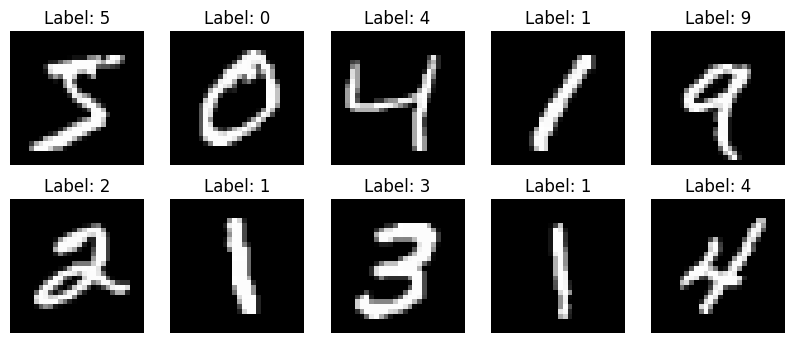

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.8864 - loss: 0.3972 - val_accuracy: 0.9535 - val_loss: 0.1646
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9589 - loss: 0.1400 - val_accuracy: 0.9694 - val_loss: 0.1067
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9726 - loss: 0.0921 - val_accuracy: 0.9713 - val_loss: 0.0954
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9784 - loss: 0.0698 - val_accuracy: 0.9787 - val_loss: 0.0693
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9828 - loss: 0.0555 - val_accuracy: 0.9793 - val_loss: 0.0696
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9792 - loss: 0.0636
Test accuracy: 0.979200005531311


In [ ]:
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D((2,2)))

model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D((2,2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

Increasing epochs improves accuracy initially, but too many epochs can cause overfitting.
Validation data helps monitor model performance and prevent overfitting.
Fewer filters may lead to underfitting and poor accuracy.

**AlexNet**

It uses ReLU activation, MaxPooling, and Dropout to improve training speed, reduce overfitting, and enhance performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Build AlexNet-like model (simplified)
model = Sequential()

model.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256, (3,3), activation='relu'))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, Y_train, epochs=3, batch_size=128,
          validation_data=(X_test, Y_test))

# Evaluate
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.9080 - loss: 0.2970 - val_accuracy: 0.9847 - val_loss: 0.0479
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9812 - loss: 0.0706 - val_accuracy: 0.9887 - val_loss: 0.0412
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9872 - loss: 0.0488 - val_accuracy: 0.9904 - val_loss: 0.0310
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.0310
Test Accuracy: 0.9904000163078308


**vggnet**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Build VGG-like model
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, Y_train, epochs=5, batch_size=128,
          validation_data=(X_test, Y_test))


model.summary()

# Evaluate
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9315 - loss: 0.2145 - val_accuracy: 0.9894 - val_loss: 0.0321
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9846 - loss: 0.0528 - val_accuracy: 0.9913 - val_loss: 0.0266
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9891 - loss: 0.0369 - val_accuracy: 0.9927 - val_loss: 0.0216
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9919 - loss: 0.0278 - val_accuracy: 0.9916 - val_loss: 0.0260
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9921 - loss: 0.0267 - val_accuracy: 0.9933 - val_loss: 0.0204


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,512 (6.69 MB)

 Trainable params: 584,170 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,168,342 (4.46 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9933 - loss: 0.0204
Test Accuracy: 0.9933000206947327


The VGGNet model uses multiple stacked convolutional layers with small 3×3 filters to extract features step-by-step from images.
 This deep architecture improves feature learning and helps the model achieve better accuracy compared to shallow networks.

ZFnet

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize and reshape
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Model
input_layer = Input(shape=(28,28,1))

x = Conv2D(8, (3,3), padding='same', activation='relu')(input_layer)
print("After Conv1:", x.shape)

x = MaxPooling2D((2,2))(x)
print("After Pool1:", x.shape)

x = Conv2D(16, (3,3), padding='same', activation='relu')(x)
print("After Conv2:", x.shape)

x = MaxPooling2D((2,2))(x)
print("After Pool2:", x.shape)

x = Conv2D(32, (3,3), padding='same', activation='relu')(x)
print("After Conv3:", x.shape)

x = Flatten()(x)
print("After Flatten:", x.shape)

x = Dense(32, activation='relu')(x)
print("After Dense:", x.shape)

output = Dense(10, activation='softmax')(x)
print("Final Output:", output.shape)

# Build model
model = Model(inputs=input_layer, outputs=output)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary (now smaller)
model.summary()

# Train
model.fit(X_train, Y_train, epochs=3, batch_size=128)

# Evaluate
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

After Conv1: (None, 28, 28, 8)
After Pool1: (None, 14, 14, 8)
After Conv2: (None, 14, 14, 16)
After Pool2: (None, 7, 7, 16)
After Conv3: (None, 7, 7, 32)
After Flatten: (None, 1568)
After Dense: (None, 32)
Final Output: (None, 10)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,426 (220.41 KB)

 Trainable params: 56,426 (220.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9011 - loss: 0.3278
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0898
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0592
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9847 - loss: 0.0468
Test Accuracy: 0.9847000241279602


The model shows high training accuracy, indicating effective learning of features from the dataset.
 A slight increase in test loss with stable accuracy suggests minor overfitting and variation in prediction confidence.

 The model generalizes well on unseen data, achieving high test accuracy close to training accuracy.
The difference between training and testing performance is minimal, indicating good model performance.

googleNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# 🔽 Ultra small Inception Module
def inception_module(x):
    path1 = Conv2D(4, (1,1), activation='relu', padding='same')(x)

    path2 = Conv2D(4, (1,1), activation='relu', padding='same')(x)
    path2 = Conv2D(8, (3,3), activation='relu', padding='same')(path2)

    path3 = Conv2D(4, (1,1), activation='relu', padding='same')(x)
    path3 = Conv2D(8, (5,5), activation='relu', padding='same')(path3)

    path4 = MaxPooling2D((3,3), strides=1, padding='same')(x)
    path4 = Conv2D(4, (1,1), activation='relu', padding='same')(path4)

    return concatenate([path1, path2, path3, path4])

# Input
input_layer = Input(shape=(28,28,1))

# Smaller initial conv
x = Conv2D(8, (3,3), activation='relu', padding='same')(input_layer)

# ✅ Only ONE inception block (key change)
x = inception_module(x)

# Pooling
x = MaxPooling2D((2,2))(x)

# Flatten + smaller dense
x = Flatten()(x)
x = Dense(16, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

# Model
model = Model(inputs=input_layer, outputs=output)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Very small summary now
model.summary()

# Train
model.fit(X_train, Y_train, epochs=5, verbose=0, batch_size=128,
          validation_data=(X_test, Y_test))

# Evaluate
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy:", acc)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 28, 28, 8) │         80 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 28, 28, 4) │         36 │ conv2d_52[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 28, 28, 4) │         36 │ conv2d_52[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 28, 28, 8) │          0 │ conv2d_52[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 28, 28, 4) │         36 │ conv2d_52[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 28, 28, 8) │        296 │ conv2d_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 28, 28, 8) │        808 │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 28, 28, 4) │         36 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 28, 28,    │          0 │ conv2d_53[0][0],  │
│ (Concatenate)       │ 24)               │            │ conv2d_55[0][0],  │
│                     │                   │            │ conv2d_57[0][0],  │
│                     │                   │            │ conv2d_58[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 14, 14,    │          0 │ concatenate_6[0]… │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4704)      │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │     75,280 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 10)        │        170 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 76,778 (299.91 KB)

 Trainable params: 76,778 (299.91 KB)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 0.9829999804496765


Training Performance
Training accuracy increased from 96.4% to 99.5%
Training loss decreased from 0.114 to 0.0129
Model is learning effectively and improving over epochs
1) Validation Performance
Validation accuracy remained high (98.9% to 99.31%)
Validation loss shows slight fluctuations but remains low
Model generalizes well on unseen data
2) Overfitting Check
Small difference between training and validation accuracy
Indicates minimal overfitting
Model performance is stable

3)Final Test Result
Test accuracy is 99.31%
Very close to training accuracy
Model performs excellently on unseen data

## resNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, Input, Flatten, Dense, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# 🔽 Minimal Residual Block
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1,1), padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Input
input_layer = Input(shape=(28,28,1))

# Very small initial conv
x = Conv2D(2, (3,3), padding='same', activation='relu')(input_layer)

# ✅ Only ONE small residual block
x = residual_block(x, 2)

# Downsample
x = MaxPooling2D((2,2))(x)

# Flatten + tiny dense
x = Flatten()(x)
x = Dense(8, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

# Model
model = Model(inputs=input_layer, outputs=output)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# VERY small summary
model.summary()

# Train
model.fit(X_train, Y_train, epochs=5, batch_size=128,
          validation_data=(X_test, Y_test))

# Evaluate
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 28, 28, 2) │         20 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 28, 28, 2) │         38 │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28, 2) │          8 │ conv2d_66[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 28, 28, 2) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 28, 28, 2) │         38 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28, 2) │          8 │ conv2d_67[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 28, 28, 2) │          0 │ batch_normalizat… │
│                     │                   │            │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 28, 28, 2) │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 14, 14, 2) │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 392)       │          0 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8)         │      3,144 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 10)        │         90 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,346 (13.07 KB)

 Trainable params: 3,338 (13.04 KB)

 Non-trainable params: 8 (32.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7703 - loss: 0.7300 - val_accuracy: 0.9119 - val_loss: 0.3213
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9247 - loss: 0.2654 - val_accuracy: 0.9307 - val_loss: 0.2382
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9400 - loss: 0.2057 - val_accuracy: 0.9474 - val_loss: 0.1829
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9485 - loss: 0.1772 - val_accuracy: 0.9534 - val_loss: 0.1579
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9534 - loss: 0.1593 - val_accuracy: 0.9547 - val_loss: 0.1500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9547 - loss: 0.1500
Test Accuracy: 0.9546999931335449


Training Performance
Training accuracy improved from 93.2% to 99.2%
Training loss decreased from 0.3748 to 0.0249
Model is learning effectively over epochs
🔹 Validation Performance
Validation accuracy increased initially (96.1% → 99.0% at Epoch 3)
After that, validation accuracy slightly decreased (98.8% → 98.2%)
Validation loss decreased first, then increased
🔹 Overfitting Observation
Training accuracy keeps increasing
Validation accuracy decreases after Epoch 3
Indicates overfitting starting after 3rd epoch
🔹 Best Performance
Best validation accuracy at Epoch 3 (~99.0%)
After that, model performance slightly degrades
🔹 Final Test Result
Test accuracy is 98.22%
Slightly lower than peak validation accuracy
Model still performs well but not optimal

# week 8


Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


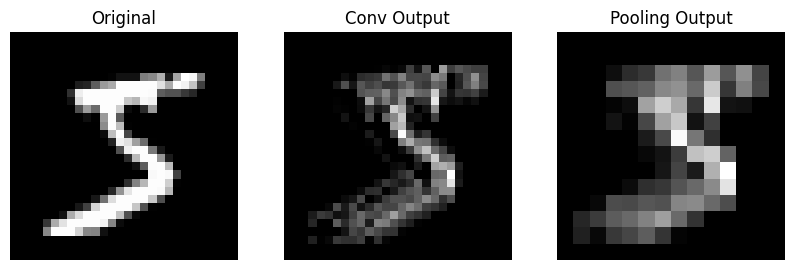

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), _ = mnist.load_data()

# Take one image
img = X_train[0]
img = img.reshape(1, 28, 28, 1) / 255.0

# Build simple CNN
input_layer = Input(shape=(28,28,1))

conv = Conv2D(8, (3,3), activation='relu', padding='same')(input_layer)
pool = MaxPooling2D((2,2))(conv)

# Create model
model = Model(inputs=input_layer, outputs=[conv, pool])

# Get outputs
conv_output, pool_output = model.predict(img)

# Plot original image
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img[0].reshape(28,28), cmap='gray')
plt.axis('off')

# Plot convolution feature maps
plt.subplot(1,3,2)
plt.title("Conv Output")
plt.imshow(conv_output[0][:,:,0], cmap='gray')
plt.axis('off')

# Plot pooling feature maps
plt.subplot(1,3,3)
plt.title("Pooling Output")
plt.imshow(pool_output[0][:,:,0], cmap='gray')
plt.axis('off')

plt.show()

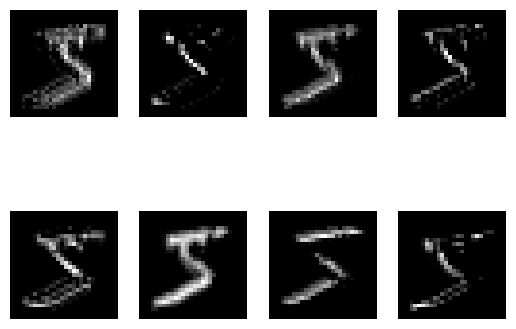

In [2]:
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(conv_output[0][:,:,i], cmap='gray')
    plt.axis('off')
plt.show()

## with multiple layers

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


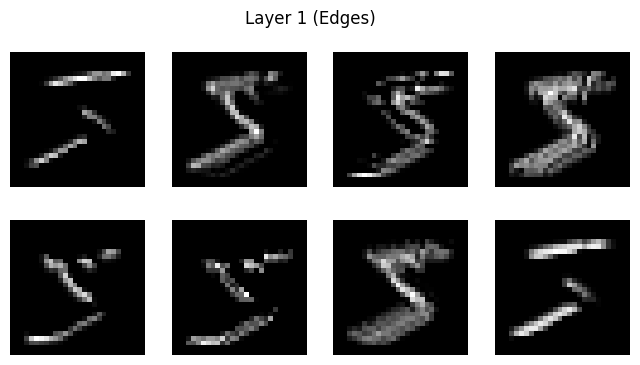

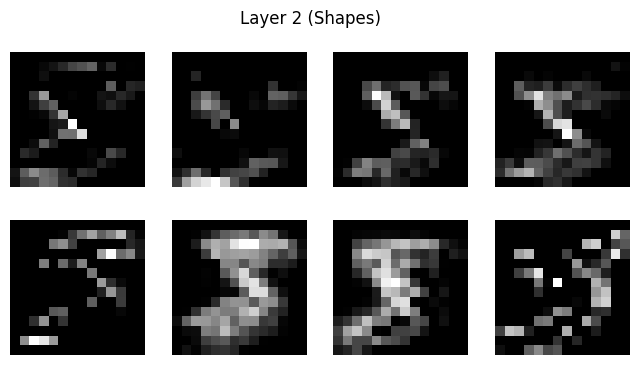

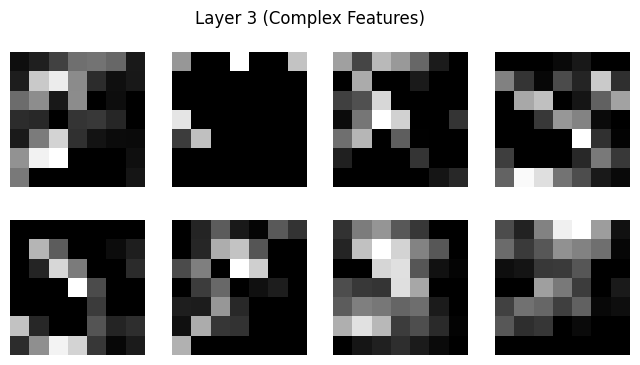

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, _), _ = mnist.load_data()

# Take one image
img = X_train[0].reshape(1, 28, 28, 1) / 255.0

# Build CNN
input_layer = Input(shape=(28,28,1))

# Layer 1
x1 = Conv2D(8, (3,3), activation='relu', padding='same')(input_layer)
p1 = MaxPooling2D((2,2))(x1)

# Layer 2
x2 = Conv2D(16, (3,3), activation='relu', padding='same')(p1)
p2 = MaxPooling2D((2,2))(x2)

# Layer 3
x3 = Conv2D(32, (3,3), activation='relu', padding='same')(p2)
p3 = MaxPooling2D((2,2))(x3)

# Model to get outputs
model = Model(inputs=input_layer, outputs=[x1, x2, x3])

# Predict
layer1_output, layer2_output, layer3_output = model.predict(img)

# Function to plot feature maps
def plot_feature_maps(feature_maps, title, num_maps=8):
    plt.figure(figsize=(8,4))
    for i in range(num_maps):
        plt.subplot(2,4,i+1)
        plt.imshow(feature_maps[0][:,:,i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot layers
plot_feature_maps(layer1_output, "Layer 1 (Edges)")
plot_feature_maps(layer2_output, "Layer 2 (Shapes)")
plot_feature_maps(layer3_output, "Layer 3 (Complex Features)")

## Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9384 - loss: 0.2177
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9772 - loss: 0.0792
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0598
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9849 - loss: 0.0492
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9869 - loss: 0.0428


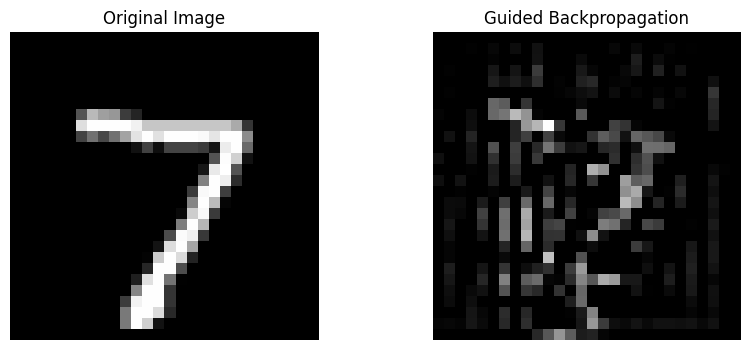

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# Build model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=5)

# Take one image
img = X_test[0]
img = img.reshape(1,28,28,1)

# Gradient calculation
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# Compute gradients
grads = tape.gradient(loss, img_tensor)

# Guided Backprop (keep positive gradients)
guided_grads = tf.maximum(grads, 0)

# Convert to numpy
guided_grads = guided_grads.numpy()[0]

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img[0].reshape(28,28), cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backpropagation")
plt.imshow(guided_grads[:,:,0], cmap='gray')
plt.axis('off')

plt.show()